Ответ: 21

# 1. Загрузите данные из файла abalone.csv. Это датасет, в котором требуется предсказать возраст ракушки (число колец) по физическим измерениям.

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold, cross_val_score
import matplotlib.pyplot as plt

data = pd.read_csv("/content/abalone.csv")

# 2. Преобразуйте признак Sex в числовой: значение F должно перейти в -1, I — в 0, M — в 1. Если вы используете Pandas, то подойдет следующий код: data[’Sex’] = data[’Sex’].map(lambda x: 1 if x == ’M’ else (-1 if x == ’F’ else 0))


In [2]:
data['Sex'] = data['Sex'].map(lambda x: 1 if x == 'M' else (-1 if x == 'F' else 0))

# 3. Разделите содержимое файлов на признаки и целевую переменную. В последнем столбце записана целевая переменная, в остальных — признаки.

In [3]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# 4. Обучите случайный лес (sklearn.ensemble.RandomForestRegressor) с различным числом деревьев: от 1 до 50 (random_state=1). Для каждого из вариантов оцените качество работы полученного леса на кросс-валидации по 5 блокам. Используйте параметры "random_state=1"и "shuffle=True"при создании генератора кроссвалидации sklearn.cross_validation.KFold. В качестве меры качества воспользуйтесь коэффициентом детерминации (sklearn.metrics.r2_score).

In [5]:
kf = KFold(n_splits=5, shuffle=True, random_state=1)
results = []

for n in range(1, 51):
    clf = RandomForestRegressor(n_estimators=n, random_state=1)
    score = cross_val_score(clf, X, y, cv=kf, scoring='r2').mean()
    results.append(score)

# 5. Определите, при каком минимальном количестве деревьев случайный лес показывает качество на кросс-валидации выше 0.52. Это количество и будет ответом на задание.

In [6]:
n_min = 0
for n, score in enumerate(results):
    if score > 0.52:
        n_min = n + 1
        break

print(n_min)

21


# 6. Обратите внимание на изменение качества по мере роста числа деревьев Ухудшается ли оно?

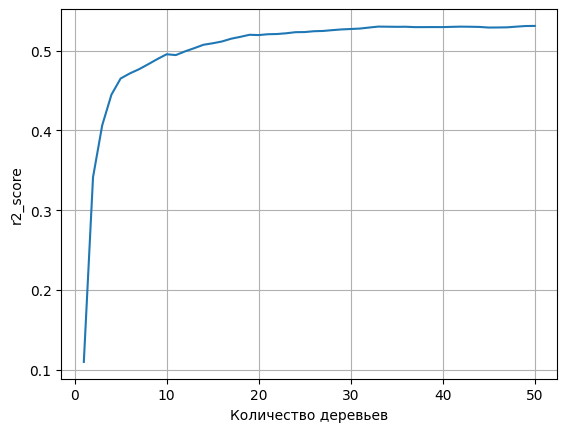

Ответ на вопрос: Качество по мере роста числа деревьев не ухудшается, оно выходит на плато (стабилизируется)


In [7]:
plt.plot(range(1, 51), results)
plt.xlabel('Количество деревьев')
plt.ylabel('r2_score')
plt.grid(True)
plt.show()

print("Ответ на вопрос: Качество по мере роста числа деревьев не ухудшается, оно выходит на плато (стабилизируется)")